In [1]:
import collections
import re
import sys
from pathlib import Path
# 把 deeplearning 目录加入模块搜索路径
d2l_dir = Path(r"C:\Users\abc\Documents\GitHub\vscodepractice\deeplearning")
sys.path.insert(0, str(d2l_dir))
import math
import numpy as np
import torch
from torch import nn
import d2l_local as d2l
import random

d2l.use_svg_display()

这段 `masked_softmax` 可以理解成：

> 做 softmax 之前，先把“不应该参与注意力计算的位置”遮住，让这些位置最终得到 0 的注意力权重。

它主要用于 Transformer 的注意力机制，避免模型把注意力放在 padding 等无效位置上。

假设：

```python
X.shape == (batch_size, query数量, key数量)
```

在 notebook 里的例子中：

```python
X.shape == (2, 2, 4)
```

含义是：

- 有 2 个样本；
- 每个样本有 2 个 query；
- 每个 query 会对 4 个 key 计算注意力分数。

---

### 先看最直观的例子

假设某一行注意力分数是：

```python
X = [1, 2, 3, 4]
valid_len = 2
```

`valid_len=2` 表示只有前两个位置有效，所以先变成：

```python
[1, 2, -1000000, -1000000]
```

再做 softmax：

```python
softmax([1, 2, -1000000, -1000000])
≈ [0.2689, 0.7311, 0, 0]
```

后两个位置被彻底排除。

不能把无效位置设为 `0`，因为：

```python
exp(0) = 1
```

它们仍然会分走一部分概率。设置成 `-1e6` 后：

```python
exp(-1e6) ≈ 0
```

所以对应的 softmax 权重约等于 0。

---

### `_sequence_mask` 在做什么

```python
maxlen = X.size(1)
```

这里的 `X` 已经被整理成二维矩阵，因此 `maxlen` 是每行有多少个位置。

例如：

```python
X.shape == (4, 4)
maxlen == 4
```

然后：

```python
torch.arange(maxlen)[None, :]
```

得到：

```python
[[0, 1, 2, 3]]
```

假设：

```python
valid_len = [2, 2, 3, 3]
```

那么：

```python
valid_len[:, None]
```

变成列向量：

```python
[[2],
 [2],
 [3],
 [3]]
```

两者比较：

```python
mask = position < valid_len
```

利用广播得到：

```python
[
 [True, True, False, False],
 [True, True, False, False],
 [True, True, True,  False],
 [True, True, True,  False]
]
```

`True` 表示有效，`False` 表示无效。

接下来：

```python
X[~mask] = -1e6
```

`~mask` 是把真假反过来，所以这句话就是：

> 把所有无效位置设置成 `-1e6`。

---

### `valid_lens` 是一维时

notebook 中：

```python
X = torch.rand(2, 2, 4)
valid_lens = torch.tensor([2, 3])
```

`valid_lens` 只有两个数字，表示每个样本的有效长度：

```text
样本0：有效长度为2
样本1：有效长度为3
```

但是每个样本有两个 query，所以同一个有效长度需要使用两次：

```python
valid_lens = torch.repeat_interleave(valid_lens, shape[1])
```

变化过程是：

```python
[2, 3]
↓
[2, 2, 3, 3]
```

然后：

```python
X.reshape(-1, shape[-1])
```

将：

```text
(2个样本, 2个query, 4个key)
```

暂时摊平成：

```text
(4行, 4个key)
```

对应关系是：

```text
样本0，query0 → 有效长度2
样本0，query1 → 有效长度2
样本1，query0 → 有效长度3
样本1，query1 → 有效长度3
```

因此输出类似：

```python
[
  [
    [有效, 有效, 0, 0],
    [有效, 有效, 0, 0]
  ],
  [
    [有效, 有效, 有效, 0],
    [有效, 有效, 有效, 0]
  ]
]
```

每一行的概率之和仍然是 1。

---

### `valid_lens` 是二维时

第二个例子：

```python
valid_lens = torch.tensor([
    [1, 3],
    [2, 4]
])
```

这次每个 query 都有自己的有效长度：

```text
样本0：
  query0只能看前1个位置
  query1只能看前3个位置

样本1：
  query0只能看前2个位置
  query1可以看前4个位置
```

代码把它展平：

```python
valid_lens.reshape(-1)
```

得到：

```python
[1, 3, 2, 4]
```

所以最终效果是：

```text
query 0：[有效, 0,    0,    0]
query 1：[有效, 有效, 有效, 0]
query 2：[有效, 有效, 0,    0]
query 3：[有效, 有效, 有效, 有效]
```

这正好对应 notebook 中看到的输出。

---

因此，整段代码的核心流程就是：

```text
注意力分数 X
    ↓
根据 valid_lens 找出无效位置
    ↓
将无效位置替换成 -1e6
    ↓
做 softmax
    ↓
无效位置权重变成 0，有效位置权重之和为 1
```

一句话记忆：

> `masked_softmax` 就是“只在允许看的位置上分配注意力概率”。

这段代码位于 [transformer3.ipynb](C:/Users/abc/Documents/GitHub/vscodepractice/deeplearning/chapter11/transformer3.ipynb:34)。

In [2]:
def masked_softmax(X, valid_lens):  #@save
    """Perform softmax operation by masking elements on the last axis."""
    # X: 3D tensor, valid_lens: 1D or 2D tensor
    def _sequence_mask(X, valid_len, value=0):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype=torch.float32,
                            device=X.device)[None, :] < valid_len[:, None]
        X[~mask] = value#~mask 是把真假反过来，所以这句话就是：将 mask 为 False 的元素设为 value
        return X

    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            #torch.repeat_interleave() 函数的作用是将输入张量的每个元素沿指定维度重复一定次数，返回一个新的张量。
            #与repeat()函数不同，repeat_interleave()函数会将每个元素连续复制一定次数，而不是将整个张量沿指定维度复制。
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # On the last axis, replace masked elements with a very large negative
        # value, whose exponentiation outputs 0
        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [3]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))
# 含义是：
# - 有 2 个样本；
# - 每个样本有 2 个 query；
# - 每个 query 会对 4 个 key 计算注意力分数。

tensor([[[0.5304, 0.4696, 0.0000, 0.0000],
         [0.5944, 0.4056, 0.0000, 0.0000]],

        [[0.2426, 0.4303, 0.3271, 0.0000],
         [0.2696, 0.4767, 0.2537, 0.0000]]])

In [4]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.3384, 0.2781, 0.3835, 0.0000]],

        [[0.6835, 0.3165, 0.0000, 0.0000],
         [0.2343, 0.3266, 0.2147, 0.2245]]])

In [5]:
# Q = torch.ones((2, 3, 4))
# K = torch.ones((2, 4, 6))
# d2l.check_shape(torch.bmm(Q, K), (2, 3, 6))

In [ ]:
class DotProductAttention(nn.Module):  #@save
    """Scaled dot product attention."""
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout) #用于训练时随机丢弃部分注意力权重，减少过拟合

    # Shape of queries: (batch_size, no. of queries, d)
    # Shape of keys: (batch_size, no. of key-value pairs, d)
    # Shape of values: (batch_size, no. of key-value pairs, value dimension)
    # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # Swap the last two dimensions of keys with keys.transpose(1, 2)
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d) #keys.transpose:    (batch_size, d, key数量)
        key_norm2=keys.square().sum(dim=-1)#沿最后一个维度求和：相当于把所有的特征平方后求和，得到每个 key 的平方范数
        scores = scores - 0.5 * key_norm2.unsqueeze(1)
        self.attention_weights = masked_softmax(scores, valid_lens)#得到的 scores 表示：每个 query 对每个 key 的匹配程度。
        return torch.bmm(self.dropout(self.attention_weights), values)#torch.bmm 是 批量矩阵乘法（batch matrix multiplication）。

In [21]:
# 2：batch_size，有 2 个样本
# 1：每个样本有 1 个 query
# 2：每个 query 有 2 个特征
queries = torch.normal(0, 1, (2, 1, 2))
keys = torch.normal(0, 1, (2, 10, 2))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([2, 6])

attention = DotProductAttention(dropout=0.5)
attention.eval()#会让dropout层在前向传播时不丢弃任何神经元，保证输出的稳定性。但并不等于关闭梯度
d2l.check_shape(attention(queries, keys, values, valid_lens), (2, 1, 4))

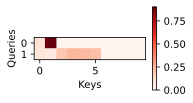

In [22]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

In [17]:
class AdditiveAttention(nn.Module):  #@save
    """Additive attention."""
    #做一次分别映射，然后再相加，最后再映射成一个标量
    def __init__(self, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        #lazylinear: 线性层的输入特征数可以在第一次调用时自动推断出来，而不需要在初始化时指定。
        self.W_k = nn.LazyLinear(num_hiddens, bias=False)
        self.W_q = nn.LazyLinear(num_hiddens, bias=False)
        self.w_v = nn.LazyLinear(1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # After dimension expansion, shape of queries: (batch_size, no. of
        # queries, 1, num_hiddens) and shape of keys: (batch_size, 1, no. of
        # key-value pairs, num_hiddens). Sum them up with broadcasting
        features = queries.unsqueeze(2) + keys.unsqueeze(1)#unsqueeze 用于在张量指定位置增加一个长度为 1 的维度。
        features = torch.tanh(features)
        # There is only one output of self.w_v, so we remove the last
        # one-dimensional entry from the shape. Shape of scores: (batch_size,
        # no. of queries, no. of key-value pairs)
        scores = self.w_v(features).squeeze(-1)#squeeze 删除长度为 1 的维度
        self.attention_weights = masked_softmax(scores, valid_lens)
        # Shape of values: (batch_size, no. of key-value pairs, value
        # dimension)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [18]:
queries = torch.normal(0, 1, (2, 1, 20))

attention = AdditiveAttention(num_hiddens=8, dropout=0.1)
attention.eval()
d2l.check_shape(attention(queries, keys, values, valid_lens), (2, 1, 4))

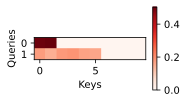

In [19]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')